In [35]:
%pip install pandas sqlalchemy psycopg2-binary pymysql


Note: you may need to restart the kernel to use updated packages.


In [36]:
# Loading the dataset using pandas

import pandas as pd

df = pd.read_csv('customer_shopping_behavior.csv')

In [37]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [39]:
# Summary statistics using .describe()
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [40]:
# Checking if missing data or null values are present in the dataset

df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [41]:
# Imputing missing values in Review Rating column with the median rating of the product category

df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [42]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [43]:
# Renaming columns according to snake casing for better readability and documentation

df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [44]:

df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [45]:
# create a new column age_group
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels = labels)


In [46]:
# This shows you the exact range brackets along with how many rows fall into each
print(pd.qcut(df['age'], q=4).value_counts().sort_index())

age
(17.999, 31.0]    1028
(31.0, 44.0]       942
(44.0, 57.0]       986
(57.0, 70.0]       944
Name: count, dtype: int64


In [47]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [48]:
# create new column purchase_frequency_days

frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [49]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [50]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [51]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [52]:
# Dropping promo code used column

df = df.drop('promo_code_used', axis=1)

In [53]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='str')

In [54]:
from sqlalchemy import create_engine

# Step 1: Connect to PostgreSQL
# Replace placeholders with your actual details

username = "dilshanrajapakshe"  # Your macOS username
password = ""                   # No password needed for local Homebrew setup
host = "localhost"
port = "5432"          # default PostgreSQL port
database = "customer_behavior"    # the database you created in pgAdmin

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into PostgreSQL
table_name = "customer"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'customer' in database 'customer_behavior'.


In [55]:
%pip install matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


## 📊 Data Visualization Dashboard

Below are the visualizations representing key insights from the customer shopping behavior dataset.

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic style for charts
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

/var/folders/3n/0sbptp8d01lfs7y4cdnnnprh0000gn/T/ipykernel_13446/3144877927.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gender_revenue, x='gender', y='purchase_amount', palette='Set2')


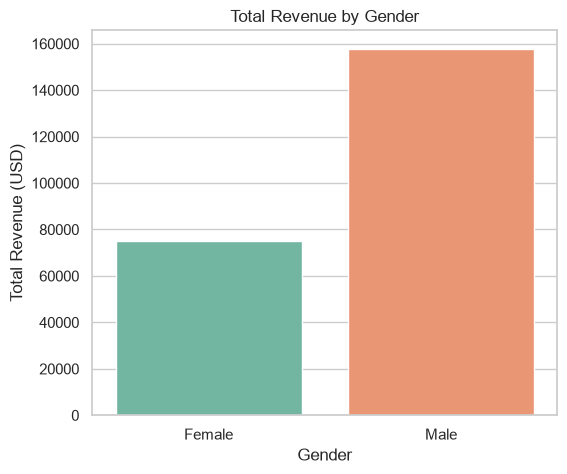

In [57]:
# Q1: Total revenue generated by male vs. female customers
gender_revenue = df.groupby('gender')['purchase_amount'].sum().reset_index()

plt.figure(figsize=(6, 5))
sns.barplot(data=gender_revenue, x='gender', y='purchase_amount', palette='Set2')
plt.title('Total Revenue by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Revenue (USD)')
plt.show()

/var/folders/3n/0sbptp8d01lfs7y4cdnnnprh0000gn/T/ipykernel_13446/3253989315.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5_products, x='review_rating', y='item_purchased', palette='viridis')


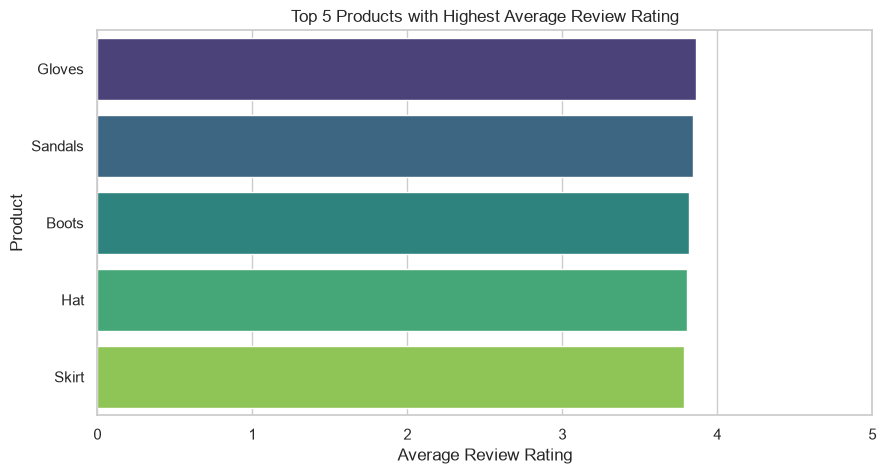

In [58]:
# Q3: Top 5 products with the highest average review rating
top_products = df.groupby('item_purchased')['review_rating'].mean().reset_index()
top_5_products = top_products.sort_values(by='review_rating', ascending=False).head(5)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_5_products, x='review_rating', y='item_purchased', palette='viridis')
plt.title('Top 5 Products with Highest Average Review Rating')
plt.xlabel('Average Review Rating')
plt.ylabel('Product')
plt.xlim(0, 5)
plt.show()

/var/folders/3n/0sbptp8d01lfs7y4cdnnnprh0000gn/T/ipykernel_13446/3585152049.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=shipping_compare, x='shipping_type', y='purchase_amount', palette='Pastel1')


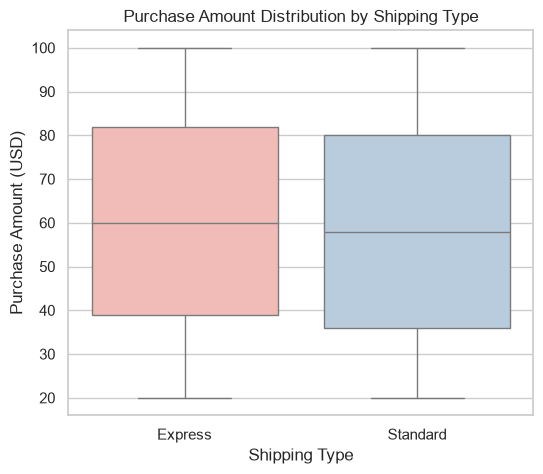

In [59]:
# Q4: Compare the average Purchase Amounts between Standard and Express Shipping
shipping_compare = df[df['shipping_type'].isin(['Standard', 'Express'])]

plt.figure(figsize=(6, 5))
sns.boxplot(data=shipping_compare, x='shipping_type', y='purchase_amount', palette='Pastel1')
plt.title('Purchase Amount Distribution by Shipping Type')
plt.xlabel('Shipping Type')
plt.ylabel('Purchase Amount (USD)')
plt.show()

/var/folders/3n/0sbptp8d01lfs7y4cdnnnprh0000gn/T/ipykernel_13446/2186926887.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=sub_metrics, x='subscription_status', y='mean', palette='coolwarm')
/var/folders/3n/0sbptp8d01lfs7y4cdnnnprh0000gn/T/ipykernel_13446/2186926887.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=sub_metrics, x='subscription_status', y='sum', palette='coolwarm')


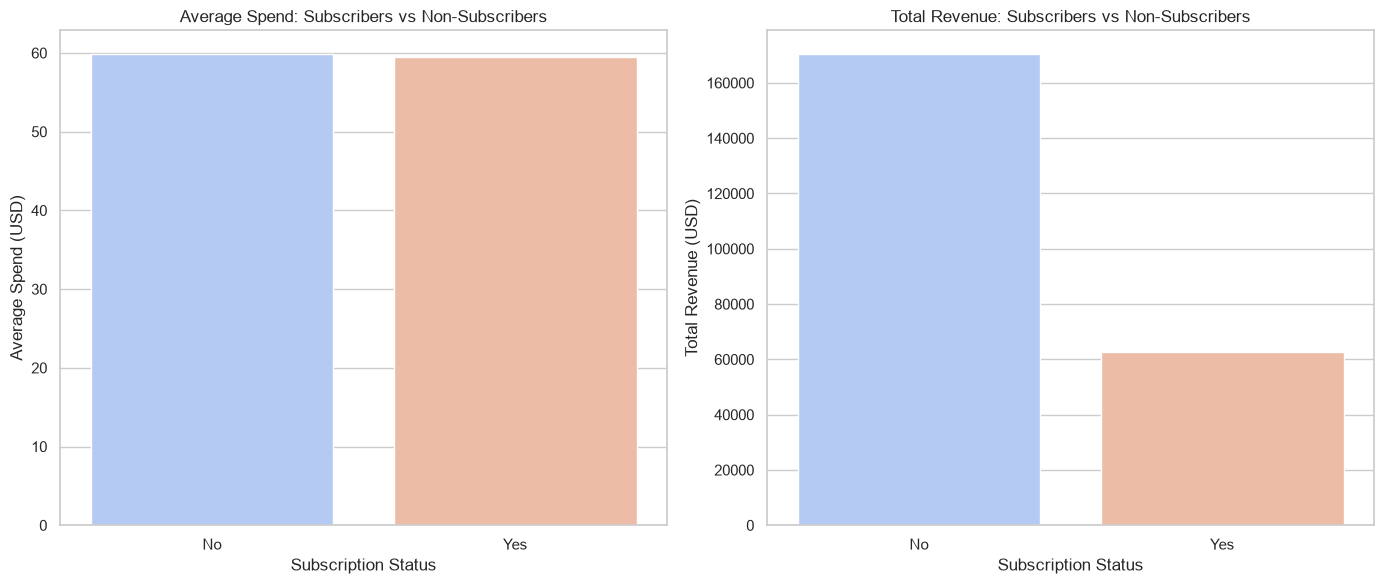

In [60]:
# Q5: Do subscribed customers spend more? Compare average spend and total revenue
sub_metrics = df.groupby('subscription_status')['purchase_amount'].agg(['mean', 'sum']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Average Spend
sns.barplot(ax=axes[0], data=sub_metrics, x='subscription_status', y='mean', palette='coolwarm')
axes[0].set_title('Average Spend: Subscribers vs Non-Subscribers')
axes[0].set_xlabel('Subscription Status')
axes[0].set_ylabel('Average Spend (USD)')

# Total Revenue
sns.barplot(ax=axes[1], data=sub_metrics, x='subscription_status', y='sum', palette='coolwarm')
axes[1].set_title('Total Revenue: Subscribers vs Non-Subscribers')
axes[1].set_xlabel('Subscription Status')
axes[1].set_ylabel('Total Revenue (USD)')

plt.tight_layout()
plt.show()

### 🚀 Additional Business Growth Insights

The following visualizations help analyze seasonal demand, discount effectiveness, and demographic payment preferences to optimize inventory, marketing, and checkout flows.

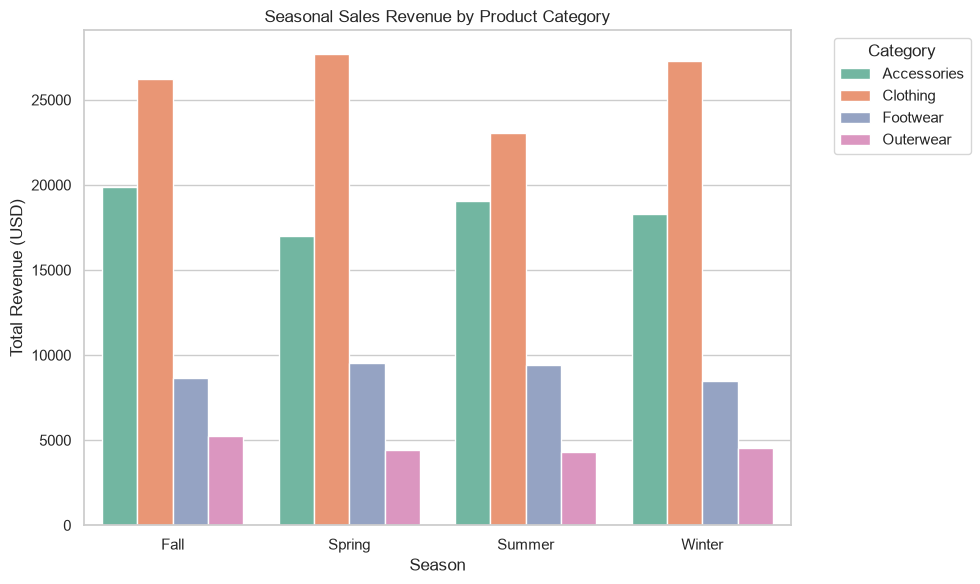

In [61]:
# Q6: Seasonal Sales Revenue by Product Category (Inventory Management)
seasonal_sales = df.groupby(['season', 'category'])['purchase_amount'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=seasonal_sales, x='season', y='purchase_amount', hue='category', palette='Set2')
plt.title('Seasonal Sales Revenue by Product Category')
plt.xlabel('Season')
plt.ylabel('Total Revenue (USD)')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

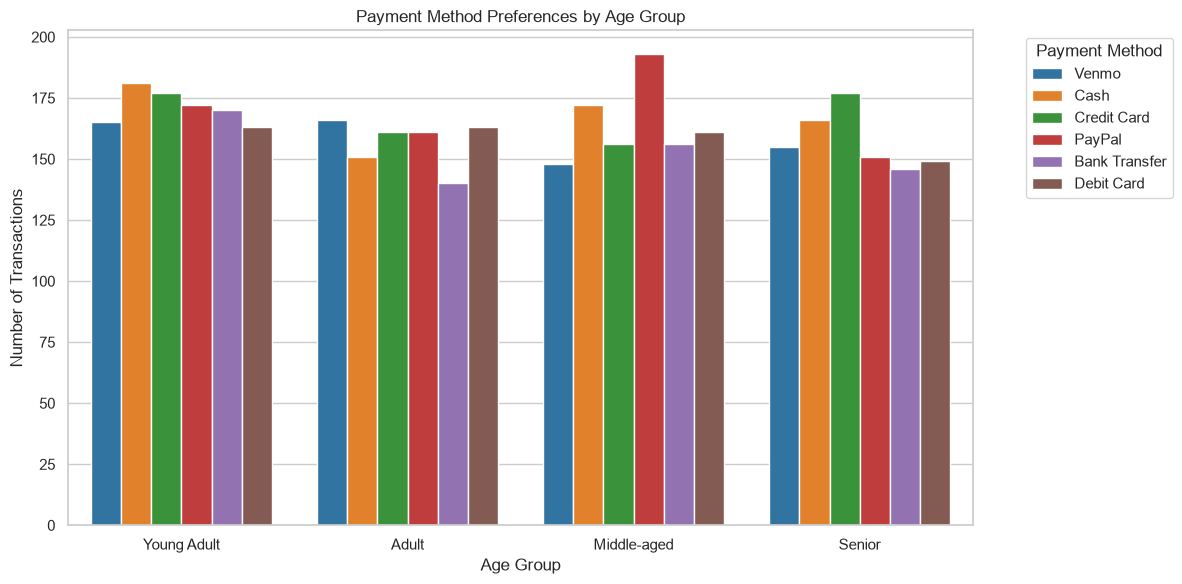

In [ ]:
# Q7: Payment Method Preferences by Age Group (Checkout Optimization)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='age_group', hue='payment_method', palette='tab10')
plt.title('Payment Method Preferences by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Transactions')
plt.legend(title='Payment Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()